In [1]:
from fyers_helper import prepare_data, load_stock_data
import datetime as dt
import pandas as pd

nifty100_df = pd.read_csv('nifty200.csv')
tickers = [ f'NSE:{n}-EQ' for n in nifty100_df.Symbol.tolist()]

data_path = "../data"

end_date = dt.datetime.now()
start_date = dt.datetime(2015, 1, 1)

file_paths = prepare_data(tickers, "1D", start_date=start_date, end_date=end_date, path=data_path, overwrite=False)
loaded_data = load_stock_data(file_paths, data_path, "1D")
df = pd.concat(loaded_data, names=["Stock", "Date"]).reset_index()

Loading 1Dmin data: 100%|██████████| 200/200 [00:00<00:00, 487.55it/s]


In [2]:
from sklearn.linear_model import LinearRegression

def calculate_rolling_slope_fitness_score(window):
    def wrap(group):
        results = []
        group = group.reset_index(drop=True)
        group['Date_ordinal'] = group['Date'].map(lambda x: x.toordinal())
        for i in range(len(group) - window + 1):
            window_df = group.iloc[i:i+window]
            X = window_df['Date_ordinal'].values.reshape(-1, 1)
            y = window_df['Close'].values
            model = LinearRegression().fit(X, y)
            slope = model.coef_[0]
            fitness = model.score(X, y)  # R² score
            results.append(slope * fitness)
        group[f'score_{window}'] = pd.Series(results)
        group[f'score_{window}'] = group[f'score_{window}'].shift(window)
        return group
    return wrap
    

# Usage:
for i in range(2, 22):
    df = df.groupby('Stock', group_keys=False).apply(calculate_rolling_slope_fitness_score(i))

for i in range(1, 8):
    df[f'exit_time_{i}'] = df.groupby('Stock')['Date'].shift(-i-1)
    df[f'exit_price_{i}'] = df.groupby('Stock')['Close'].shift(-i-1)

/var/folders/rw/xc9yc4151v3_3lcv8h2n7pxr0000gn/T/ipykernel_11448/1547912401.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('Stock', group_keys=False).apply(calculate_rolling_slope_fitness_score(i))
/var/folders/rw/xc9yc4151v3_3lcv8h2n7pxr0000gn/T/ipykernel_11448/1547912401.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('Stock', group_keys=False).apply(calculate_rolling_slop

In [3]:
from lib import PositionManager, generate_tearsheet
from tqdm.notebook import tqdm


def backtest(_df, pm: PositionManager, params, show_pb=False):
    initial_capital = params['initial_capital']
    top_n = int(params['top_n'])
    lookback_period = int(params['lookback_period'])
    holding_period = int(params['holding_period'])
    slippage = params['slippage']
    contrarian = params['contrarian']
    start_date = params['start_date']
    end_date = params['end_date']

    _df = _df.dropna(subset=[f'score_{lookback_period}'])
    _df = _df[(_df.Date >= start_date) & (_df.Date < end_date)].reset_index()

    if show_pb:
        pb = tqdm(total=_df.Date.nunique(), desc="Backtesting...")

    for idx, group in _df.groupby('Date'):
        nlargest = group[group.Open < 10000].nlargest(top_n, f'score_{lookback_period}')
        nsmallest = group[group.Open < 10000].nsmallest(top_n, f'score_{lookback_period}')
        capital = round(pm.bank.total_capital() / (top_n * 2), 2)

        slippage = slippage if contrarian else -slippage
        for stock in nlargest.itertuples():
            entry_price = stock.Open * (1 + slippage)
            pm.new_position(stock.Stock, idx, entry_price, capital, -1 if contrarian else 1)

        for stock in nsmallest.itertuples():
            entry_price = stock.Open * (1 - slippage)
            pm.new_position(stock.Stock, idx, entry_price, capital, 1 if contrarian else -1)

        for _, stock in nlargest.iterrows():
            exit_price = stock[f'exit_price_{holding_period}'] * (1 - slippage)
            exit_time = stock[f'exit_time_{holding_period}']
            pm.close_position(stock.Stock, exit_time, exit_price)

        for _, stock in nsmallest.iterrows():
            exit_price = stock[f'exit_price_{holding_period}'] * (1 + slippage)
            exit_time = stock[f'exit_time_{holding_period}']
            pm.close_position(stock.Stock, exit_time, exit_price)

        if show_pb:
            pb.update(1)

    if show_pb:
        pb.close()

    return generate_tearsheet(initial_capital, pm)


In [4]:
from lib import Bank, PositionManager, show_equity_curve
from copy import copy
from tqdm.notebook import tqdm

params = {
    'initial_capital': 1000000,
    'top_n': 10,
    'lookback_period': 2,
    'holding_period': 2,
    'slippage': 0,
    "contrarian": True,
    'start_date': '2015-01-01',
    'end_date': '2022-01-01',
}


perfs = []

pb = tqdm(total=len(range(2, 22)) * len(range(1, 8)) * len([False, True]))
for lookback_period in range(2, 22):
    for holding_period in range(1, 8):
        for contrarian in [False, True]:
            _params = copy(params)
            _params['lookback_period'] = lookback_period
            _params['holding_period'] = holding_period
            _params['contrarian'] = contrarian
            
            bank = Bank(params['initial_capital'])
            pm = PositionManager(bank, brokerage=0)
            tearsheet, trades = backtest(df.copy(), pm, _params, show_pb=False)
            perfs.append(((lookback_period, holding_period, contrarian), tearsheet, trades))
            pb.update(1)
pb.close()


  0%|          | 0/280 [00:00<?, ?it/s]

(3, 5, True)
                      Metrics                    Values
0                      Period  2015-01-06 to 2022-01-10
1            Starting capital                   1000000
2               Final capital                3153262.61
3                Total Trades                     34484
4                     Winners                     17659
5                      Losers                     16825
6               Profit factor                  1.035555
7       Active Position Count                         0
8   Max holding period (days)                        15
9   Avg holding period (days)                         8
10               Win Rate (%)                 51.209256
11               Total Profit                2153262.61
12                 Avg Profit               3551.405295
13                   Avg Loss               -3599.46529
14            Total Brokerage                         0
15                  Total Tax                1182645.12
16                  Total MTF      

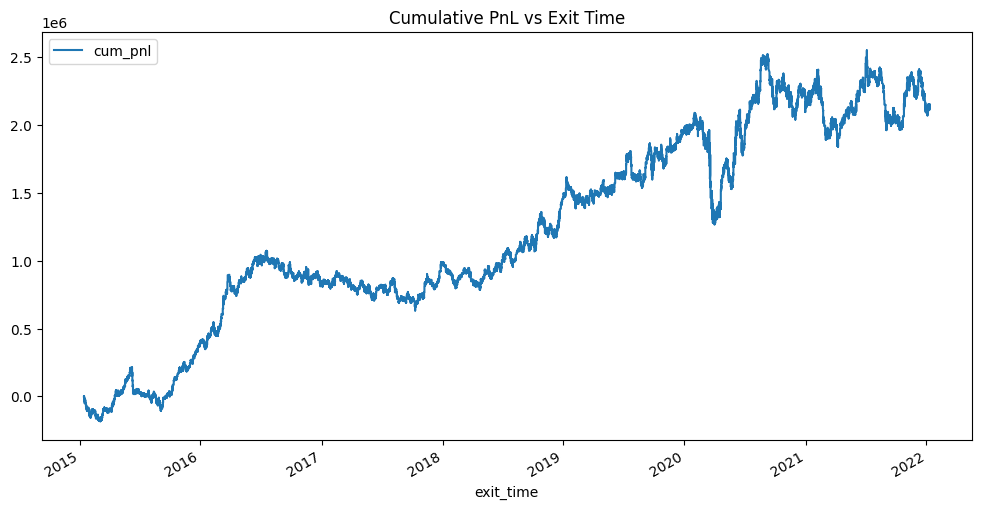

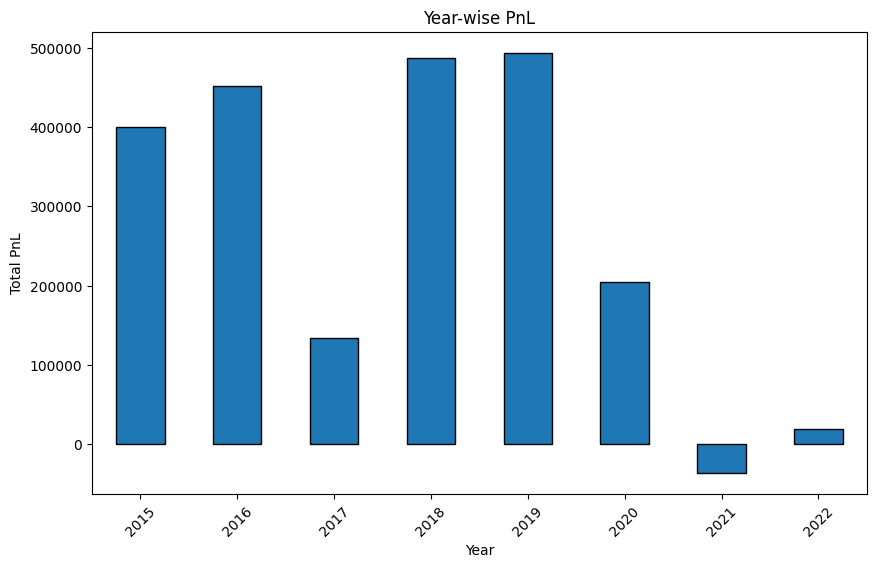

In [5]:
def comparator(a):
    return a[1]['CAGR (%)']/abs(a[1]['Max Drawdown (%)'])

sorted_perfs = sorted(perfs, key=comparator, reverse=True)

print(sorted_perfs[0][0])
print(pd.DataFrame({
    "Metrics": sorted_perfs[0][1].keys(),
    "Values": sorted_perfs[0][1].values(),
}))
show_equity_curve(sorted_perfs[0][2])